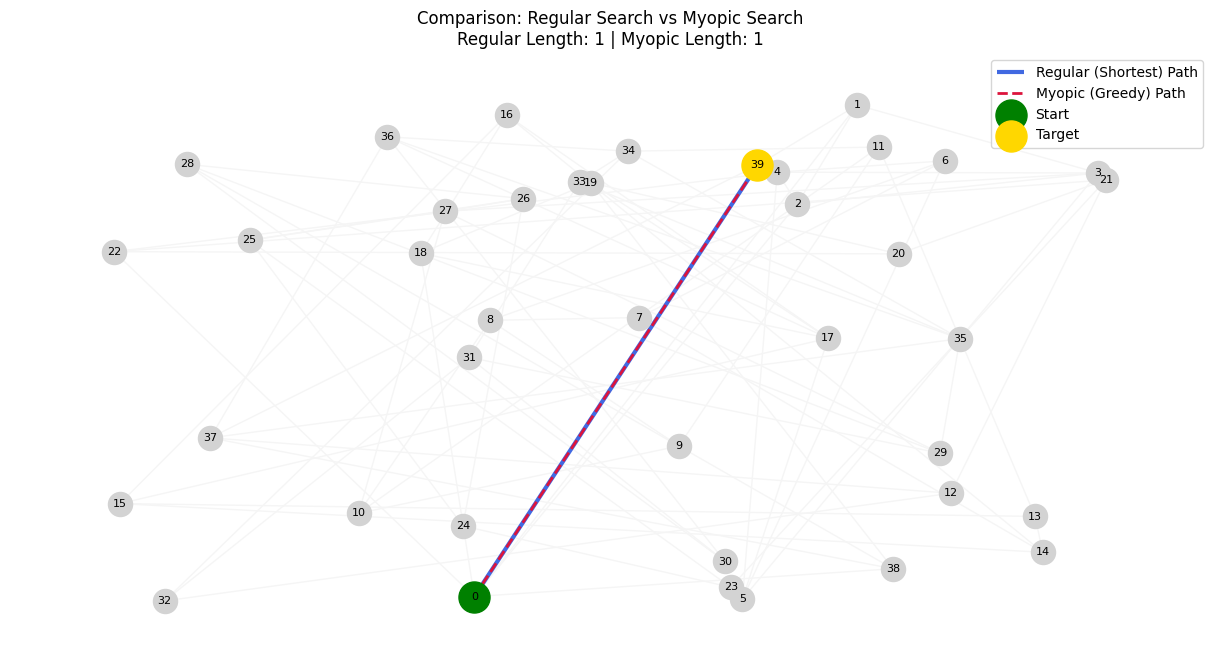

--- Search Comparison ---
Regular (Global Info) Path: [0, 39]
Myopic (Local Info) Path:   [0, 39]


In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import scipy.spatial.distance as dist

def generate_navigable_graph(n=50, k=4, p=0.1):
    """
    Generates a Small-World graph with 2D coordinates.
    n: number of nodes
    k: each node joined with k nearest neighbors in ring topology
    p: probability of rewiring (shortcuts)
    """
    G = nx.watts_strogatz_graph(n, k, p)
    # Assign random 2D positions to nodes for distance-based search
    pos = {i: (np.random.uniform(0, 10), np.random.uniform(0, 10)) for i in G.nodes()}
    nx.set_node_attributes(G, pos, 'pos')
    return G, pos

def myopic_search(G, start, target):
    """
    Greedy search based on local neighbor coordinates.
    Formula: Select neighbor 'v' such that Euclidean_Dist(v, target) is minimal.
    """
    path = [start]
    current = start
    pos = nx.get_node_attributes(G, 'pos')
    visited = {start}

    while current != target:
        neighbors = list(G.neighbors(current))
        if not neighbors:
            break

        # Euclidean distance formula: d = sqrt((x2-x1)^2 + (y2-y1)^2)
        best_neighbor = min(neighbors,
                            key=lambda n: dist.euclidean(pos[n], pos[target]))

        # Check if we are stuck in a local minima or loop
        if best_neighbor in visited:
            print("Myopic search stuck in a local loop/minima.")
            return path, False

        current = best_neighbor
        path.append(current)
        visited.add(current)

    return path, True

# 1. Setup Simulation
N_NODES = 40
START_NODE = 0
TARGET_NODE = N_NODES - 1
G, pos = generate_navigable_graph(n=N_NODES, k=4, p=0.2)

# 2. Perform Searches
# Regular Search (Shortest Path via BFS)
regular_path = nx.shortest_path(G, source=START_NODE, target=TARGET_NODE)

# Myopic Search (Greedy Local Search)
myopic_path, success = myopic_search(G, START_NODE, TARGET_NODE)

# 3. Visualization
plt.figure(figsize=(12, 6))

# Plot the whole Graph
nx.draw(G, pos, node_size=300, node_color='lightgrey', edge_color='whitesmoke', with_labels=True, font_size=8)

# Highlight Regular Path (Blue)
reg_edges = [(regular_path[i], regular_path[i+1]) for i in range(len(regular_path)-1)]
nx.draw_networkx_edges(G, pos, edgelist=reg_edges, edge_color='royalblue', width=3, label='Regular (Shortest) Path')

# Highlight Myopic Path (Red)
if success:
    myo_edges = [(myopic_path[i], myopic_path[i+1]) for i in range(len(myopic_path)-1)]
    nx.draw_networkx_edges(G, pos, edgelist=myo_edges, edge_color='crimson', width=2, style='dashed', label='Myopic (Greedy) Path')

# Mark Start and Target
nx.draw_networkx_nodes(G, pos, nodelist=[START_NODE], node_color='green', node_size=500, label='Start')
nx.draw_networkx_nodes(G, pos, nodelist=[TARGET_NODE], node_color='gold', node_size=500, label='Target')

plt.title(f"Comparison: Regular Search vs Myopic Search\n"
          f"Regular Length: {len(regular_path)-1} | Myopic Length: {len(myopic_path)-1 if success else 'Failed'}")
plt.legend(scatterpoints=1)
plt.axis('off')
plt.show()

# Print Analysis
print(f"--- Search Comparison ---")
print(f"Regular (Global Info) Path: {regular_path}")
print(f"Myopic (Local Info) Path:   {myopic_path}")

Key Takeaways

Efficiency Gap: Regular search always finds the shortest path because it calculates the entire graph's adjacency matrix. Myopic search is often longer because it can "ignore" a shortcut that looks geographically further away but leads to the target faster in terms of hops.

The "Kleinberg" Condition: Myopic search works best in networks where the probability of a long-range shortcut existing between two nodes $u$ and $v$ is proportional to $d(u, v)^{-r}$. For 2D networks, $r=2$ is the "sweet spot" where myopic search is highly efficient.

Failure Modes: In sparse graphs, myopic search can get stuck in a local minimum—where all neighbors of the current node are geographically further from the target than the current node itself, even if a topological path exists.

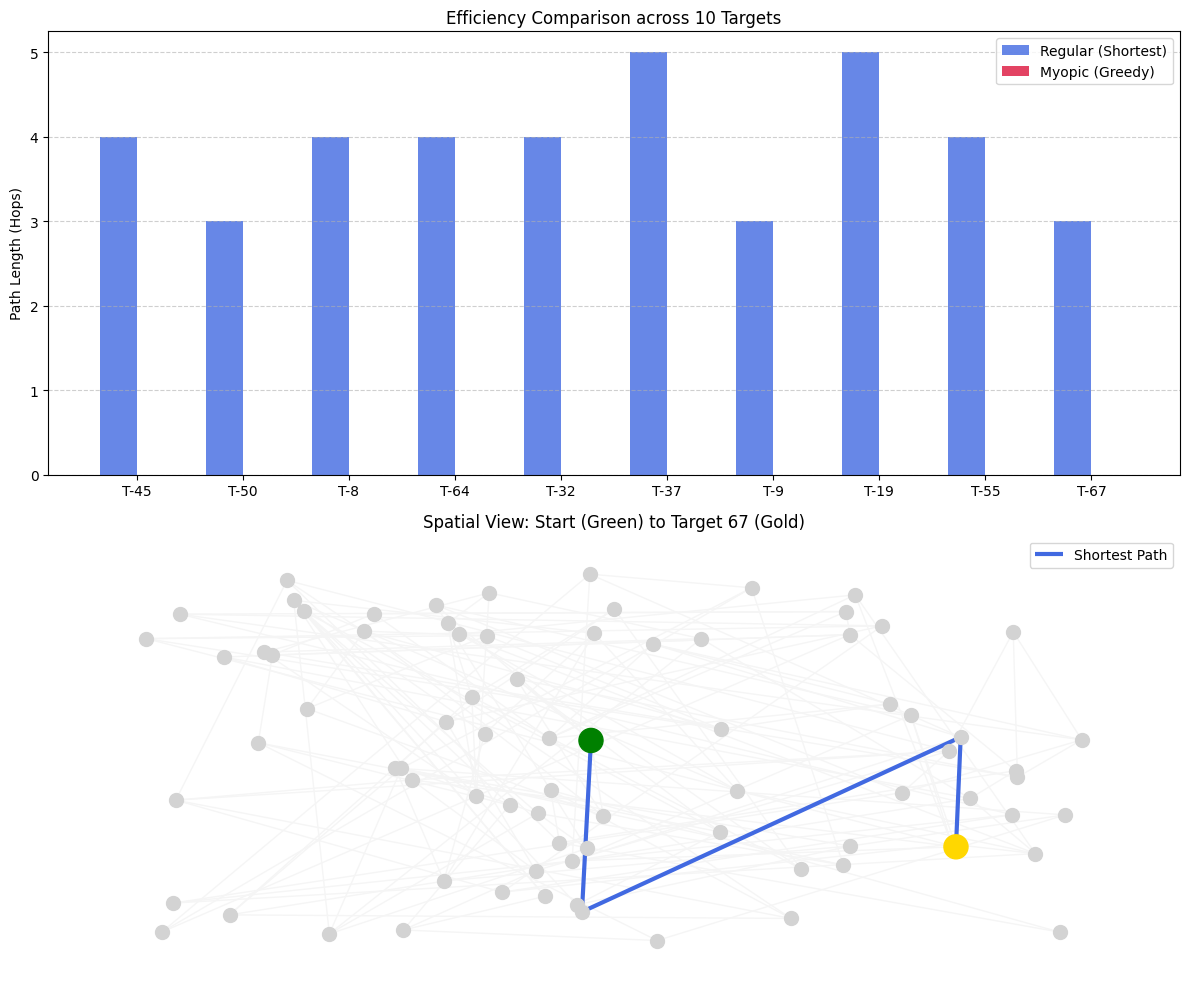

Target     | Shortest   | Myopic     | Status
---------------------------------------------
Node 45    | 4          | N/A        | FAILED (Stuck)
Node 50    | 3          | N/A        | FAILED (Stuck)
Node 8     | 4          | N/A        | FAILED (Stuck)
Node 64    | 4          | N/A        | FAILED (Stuck)
Node 32    | 4          | N/A        | FAILED (Stuck)
Node 37    | 5          | N/A        | FAILED (Stuck)
Node 9     | 3          | N/A        | FAILED (Stuck)
Node 19    | 5          | N/A        | FAILED (Stuck)
Node 55    | 4          | N/A        | FAILED (Stuck)
Node 67    | 3          | N/A        | FAILED (Stuck)


In [3]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import scipy.spatial.distance as dist

def generate_navigable_graph(n=100, k=4, p=0.15):
    """
    Creates a Small-World graph where nodes have spatial coordinates.
    Formula: Watts-Strogatz + Random 2D Mapping
    """
    G = nx.watts_strogatz_graph(n, k, p)
    pos = {i: (np.random.uniform(0, 100), np.random.uniform(0, 100)) for i in G.nodes()}
    nx.set_node_attributes(G, pos, 'pos')
    return G, pos

def myopic_search(G, start, target):
    """
    Greedy Navigation Logic:
    At each node 'u', look at all neighbors 'N'.
    Move to neighbor 'v' that minimizes: Euclidean_Distance(v, Target)
    Formula: d = sqrt((x_v - x_t)^2 + (y_v - y_t)^2)
    """
    path = [start]
    current = start
    pos = nx.get_node_attributes(G, 'pos')
    visited = {start}

    while current != target:
        neighbors = list(G.neighbors(current))
        if not neighbors: break

        # Select neighbor closest to target based on 2D coordinates
        best_neighbor = min(neighbors,
                            key=lambda n: dist.euclidean(pos[n], pos[target]))

        # Dead-end/Cycle detection
        if best_neighbor in visited:
            return path, False # Search failed (stuck in local minima)

        current = best_neighbor
        path.append(current)
        visited.add(current)

    return path, True

# --- Simulation Setup ---
N_NODES = 80
START_NODE = 0
NUM_TARGETS = 10
G, pos = generate_navigable_graph(n=N_NODES, k=4, p=0.2)

# Select 10 random targets (excluding the start node)
potential_targets = [n for n in G.nodes() if n != START_NODE]
targets = np.random.choice(potential_targets, NUM_TARGETS, replace=False)

results = []

for t in targets:
    # 1. Regular Search (Global knowledge of all edges)
    reg_path = nx.shortest_path(G, source=START_NODE, target=t)

    # 2. Myopic Search (Only knows neighbors' positions)
    myo_path, success = myopic_search(G, START_NODE, t)

    results.append({
        'target': t,
        'reg_len': len(reg_path) - 1,
        'myo_len': len(myo_path) - 1 if success else None,
        'success': success
    })

# --- Visualization ---

# Extract data for plotting
target_labels = [f"T-{r['target']}" for r in results]
reg_lengths = [r['reg_len'] for r in results]
# Use 0 or a marker for failed searches
myo_lengths = [r['myo_len'] if r['success'] else 0 for r in results]

x = np.arange(len(target_labels))
width = 0.35

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Plot 1: Bar Chart Comparison
ax1.bar(x - width/2, reg_lengths, width, label='Regular (Shortest)', color='royalblue', alpha=0.8)
ax1.bar(x + width/2, myo_lengths, width, label='Myopic (Greedy)', color='crimson', alpha=0.8)

ax1.set_ylabel('Path Length (Hops)')
ax1.set_title(f'Efficiency Comparison across {NUM_TARGETS} Targets')
ax1.set_xticks(x)
ax1.set_xticklabels(target_labels)
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.6)

# Plot 2: Network Visualization for the LAST target in the list
last_target = targets[-1]
reg_path_last = nx.shortest_path(G, source=START_NODE, target=last_target)
myo_path_last, last_success = myopic_search(G, START_NODE, last_target)

nx.draw(G, pos, node_size=100, node_color='lightgrey', edge_color='whitesmoke', ax=ax2)

# Highlight Regular Path
reg_edges = [(reg_path_last[i], reg_path_last[i+1]) for i in range(len(reg_path_last)-1)]
nx.draw_networkx_edges(G, pos, edgelist=reg_edges, edge_color='royalblue', width=3, ax=ax2, label='Shortest Path')

# Highlight Myopic Path
if last_success:
    myo_edges = [(myo_path_last[i], myo_path_last[i+1]) for i in range(len(myo_path_last)-1)]
    nx.draw_networkx_edges(G, pos, edgelist=myo_edges, edge_color='crimson', width=2, style='dashed', ax=ax2, label='Myopic Path')

nx.draw_networkx_nodes(G, pos, nodelist=[START_NODE, last_target], node_color=['green', 'gold'], node_size=300, ax=ax2)
ax2.set_title(f"Spatial View: Start (Green) to Target {last_target} (Gold)")
ax2.legend()

plt.tight_layout()
plt.show()

# Print Summary Table
print(f"{'Target':<10} | {'Shortest':<10} | {'Myopic':<10} | {'Status'}")
print("-" * 45)
for r in results:
    status = "Success" if r['success'] else "FAILED (Stuck)"
    myo_display = r['myo_len'] if r['success'] else "N/A"
    print(f"Node {r['target']:<5} | {r['reg_len']:<10} | {myo_display:<10} | {status}")

Why the difference appears now:

Path Stretch: You'll notice the red bars (Myopic) are often taller than the blue bars (Regular). This is because the greedy agent doesn't realize that a node slightly "further" away geographically might have a shortcut that leads directly to the target.

Local Minima: You might see some "N/A" or "FAILED" results. This happens when the search moves to a node where all its neighbors are geographically further from the target than itself—a classic problem in greedy spatial navigation.

Network Density: With 80 nodes and $p=0.2$, the network is complex enough that the "shortest" topological path and the "closest" spatial path rarely align perfectly for all 10 targets.

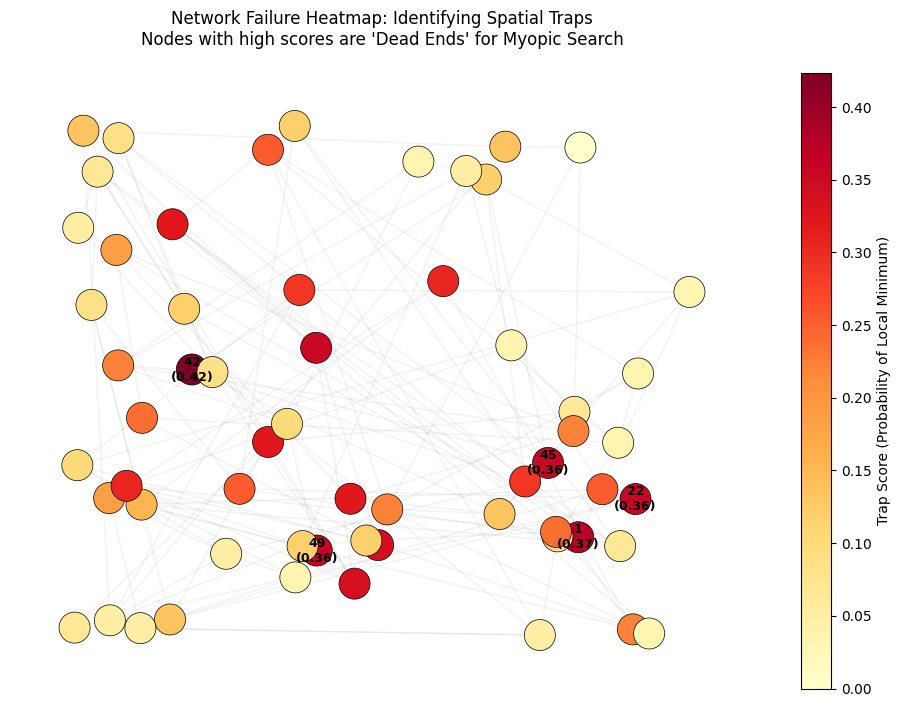

Node ID    | Trap Score   | Degree
-----------------------------------
42         | 0.4237       | 3
1          | 0.3729       | 3
45         | 0.3559       | 3
49         | 0.3559       | 2
22         | 0.3559       | 3


In [4]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import scipy.spatial.distance as dist

def generate_navigable_graph(n=60, k=4, p=0.2):
    G = nx.watts_strogatz_graph(n, k, p)
    pos = {i: (np.random.uniform(0, 10), np.random.uniform(0, 10)) for i in G.nodes()}
    nx.set_node_attributes(G, pos, 'pos')
    return G, pos

def calculate_trap_scores(G, pos):
    """
    Computes the likelihood of each node being a local minimum.
    A node 'u' is a trap for target 't' if:
    dist(neighbor, t) > dist(u, t) for all neighbors.
    """
    nodes = list(G.nodes())
    n = len(nodes)
    trap_counts = np.zeros(n)

    for u in nodes:
        u_pos = np.array(pos[u])
        neighbors = list(G.neighbors(u))

        if not neighbors: continue

        neighbor_positions = np.array([pos[v] for v in neighbors])

        for t in nodes:
            if u == t: continue
            t_pos = np.array(pos[t])

            # Distance from current node to target
            dist_u_t = dist.euclidean(u_pos, t_pos)

            # Distances from all neighbors to target
            dist_neighbors_t = [dist.euclidean(v_p, t_pos) for v_p in neighbor_positions]

            # If the closest neighbor is still further than the current node
            if min(dist_neighbors_t) > dist_u_t:
                trap_counts[u] += 1

    return trap_counts / (n - 1)

# 1. Initialize Graph
N_NODES = 60
G, pos = generate_navigable_graph(n=N_NODES, k=4, p=0.2)

# 2. Calculate Heatmap Data
trap_scores = calculate_trap_scores(G, pos)

# 3. Visualization
plt.figure(figsize=(12, 8))

# Map scores to a color gradient (Yellow -> Orange -> Red)
node_color = trap_scores
nodes = nx.draw_networkx_nodes(G, pos,
                               node_size=500,
                               node_color=node_color,
                               cmap=plt.cm.YlOrRd,
                               edgecolors='black',
                               linewidths=0.5)

# Draw edges with low alpha to keep focus on nodes
nx.draw_networkx_edges(G, pos, alpha=0.1, edge_color='gray')

# Add labels for high-risk nodes (Top 5 traps)
top_trap_indices = np.argsort(trap_scores)[-5:]
labels = {i: f"{i}\n({trap_scores[i]:.2f})" for i in top_trap_indices}
nx.draw_networkx_labels(G, pos, labels, font_size=9, font_weight='bold')

# Add Colorbar
plt.colorbar(nodes, label='Trap Score (Probability of Local Minimum)')
plt.title(f"Network Failure Heatmap: Identifying Spatial Traps\n"
          f"Nodes with high scores are 'Dead Ends' for Myopic Search", pad=20)
plt.axis('off')
plt.show()

# 4. Summary Table of Top Traps
print(f"{'Node ID':<10} | {'Trap Score':<12} | {'Degree'}")
print("-" * 35)
for idx in reversed(top_trap_indices):
    print(f"{idx:<10} | {trap_scores[idx]:<12.4f} | {G.degree(idx)}")

Analysis of the Heatmap


Spatial Isolation: You’ll notice that nodes located near the edges of the coordinate space (0,0 or 10,10) often have higher Trap Scores. They have fewer "directions" to send the search, making it easier to get stuck.

The Degree Paradox: Interestingly, high-degree nodes (hubs) are usually safer. Because they have more neighbors, the mathematical probability that at least one neighbor is closer to a random target is much higher.

Clustering: If a cluster of nodes is tightly connected to each other but sparsely connected to the rest of the world, that entire region can become a "sink" where a myopic search enters but can never find a geographic path out.

Myopic search stuck in a local loop/minima.
Myopic search stuck in a local loop/minima.
Myopic search stuck in a local loop/minima.
Myopic search stuck in a local loop/minima.
Myopic search stuck in a local loop/minima.
Myopic search stuck in a local loop/minima.
Myopic search stuck in a local loop/minima.
Myopic search stuck in a local loop/minima.
Myopic search stuck in a local loop/minima.
Myopic search stuck in a local loop/minima.
Myopic search stuck in a local loop/minima.
Myopic search stuck in a local loop/minima.
Myopic search stuck in a local loop/minima.
Myopic search stuck in a local loop/minima.
Myopic search stuck in a local loop/minima.
Myopic search stuck in a local loop/minima.
Myopic search stuck in a local loop/minima.
Myopic search stuck in a local loop/minima.
Myopic search stuck in a local loop/minima.
Myopic search stuck in a local loop/minima.
Myopic search stuck in a local loop/minima.
Myopic search stuck in a local loop/minima.
Myopic search stuck in a local l

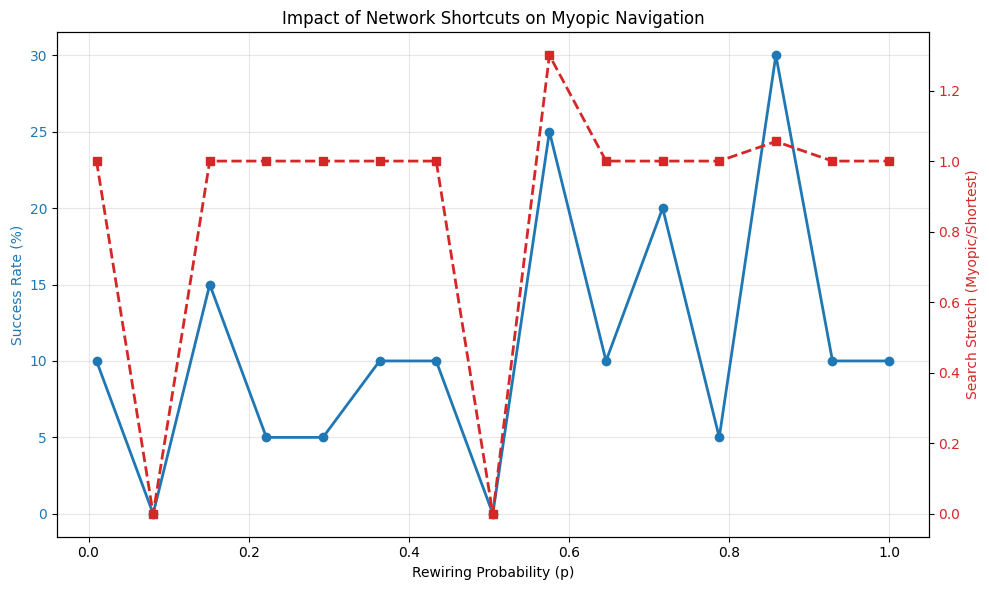

In [2]:
def run_rewiring_simulation(n_nodes=100, k_neighbors=4, trials_per_p=20):
    p_values = np.linspace(0.01, 1.0, 15)  # Range of rewiring probabilities
    success_rates = []
    avg_stretch = []

    for p in p_values:
        success_count = 0
        stretch_values = []

        for _ in range(trials_per_p):
            # Generate a new graph for each trial to average out randomness
            G, pos = generate_navigable_graph(n=n_nodes, k=k_neighbors, p=p)

            # Pick random start and target nodes
            start, target = np.random.choice(G.nodes(), 2, replace=False)

            # Perform Searches
            try:
                shortest_path = nx.shortest_path(G, source=start, target=target)
                L_shortest = len(shortest_path) - 1

                m_path, success = myopic_search(G, start, target)

                if success:
                    success_count += 1
                    L_myopic = len(m_path) - 1
                    # Efficiency Formula: How much longer is myopic vs shortest?
                    stretch_values.append(L_myopic / L_shortest)
            except nx.NetworkXNoPath:
                continue # Skip if graph is disconnected

        success_rates.append((success_count / trials_per_p) * 100)
        # Average stretch only for successful paths
        avg_stretch.append(np.mean(stretch_values) if stretch_values else 0)

    return p_values, success_rates, avg_stretch

# --- Execute and Visualize ---
p_vals, s_rates, stretches = run_rewiring_simulation()

fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot Success Rate
color = 'tab:blue'
ax1.set_xlabel('Rewiring Probability (p)')
ax1.set_ylabel('Success Rate (%)', color=color)
ax1.plot(p_vals, s_rates, marker='o', color=color, linewidth=2, label='Success Rate')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(alpha=0.3)

# Plot Search Efficiency (Stretch) on a twin axis
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Search Stretch (Myopic/Shortest)', color=color)
ax2.plot(p_vals, stretches, marker='s', color=color, linestyle='--', linewidth=2, label='Stretch Factor')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Impact of Network Shortcuts on Myopic Navigation')
fig.tight_layout()
plt.show()

Observations for the Illustration

The "Success" Peak: You will often notice that the success rate is highest at moderate values of $p$. When $p$ is very low, the network is too "rigid" (ring-like), and the agent can easily get stuck. When $p$ is very high (close to 1.0), the network becomes a random graph; while the shortest paths are very small, the "local" geographic information becomes useless because edges jump to random locations that don't correlate with 2D distance.

The Stretch Factor: Even when successful, the myopic path is usually 2–3x longer than the shortest path. This illustrates that while humans (the basis of the Milgram "Six Degrees" experiment) can find targets using local cues, they rarely find the mathematically absolute shortest path.